# Analyzing the planets in OGLE-2006-BLG-109L

In [1]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import numexpr

import astropy.units as u
import astropy.constants as c

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

In [2]:
# Distance to source plane
D_s = 8 * u.kpc

# Distance to lens plane
D_l = 1.5 * u.kpc

# Mass of star
M_star = 0.5 * c.M_sun

theta_ein, r_ein = IRSF.IRSFunctions.e_ring([D_s, D_l], M_star.to(u.M_sun).value)
print(f'Einstein ring radius: {r_ein}')
print(f'Einstein ring angle: {theta_ein}')

planets = ['False Mercury', 'False Venus', 'False Earth', 'False Mars', 'b', 'c', 'False Uranus', 'False Neptune']

# Defining our Jupiter for scale
r_jupiter = 5.2

# Defining semimajor axes of known planets
r_b = 2.3
r_c = 4.6

# Defining semimajor axes of false Solar System-like planets
r_false_uranus = 19.2 * (r_b / r_jupiter)
r_false_neptune = 30.07 * (r_b / r_jupiter)
r_false_mercury = 0.387 * (r_b / r_jupiter)
r_false_venus = 0.723 * (r_b / r_jupiter)
r_false_earth = 1 * (r_b / r_jupiter)
r_false_mars = 1.524 * (r_b / r_jupiter)

planet_semimajor_axes = np.array([r_false_mercury, r_false_venus, r_false_earth, r_false_mars, r_b, r_c, r_false_uranus, r_false_neptune]) * u.au # au

# Calculating in terms of theta_E
planet_ss = (planet_semimajor_axes / r_ein).to(u.dimensionless_unscaled).value # theta_E

# Defining our Jupiter mass for scale
m_jupiter = 1898.125e24

# Defining masses of known planets
m_b = 0.71 * c.M_jup.to(u.kg).value
m_c = 0.27 * c.M_jup.to(u.kg).value

# Defining masses of false Solar System-like planets
m_false_uranus = 86.8099e24 * (m_b / m_jupiter)
m_false_neptune = 102.4092e24 * (m_b / m_jupiter)
m_false_mercury = 0.330103e24 * (m_b / m_jupiter)
m_false_venus = 4.86731e24 * (m_b / m_jupiter)
m_false_earth = 5.97217e24 * (m_b / m_jupiter)
m_false_mars = 0.641691e24 * (m_b / m_jupiter)

planet_masses = np.array([m_false_mercury, m_false_venus, m_false_earth, m_false_mars, m_b, m_c, m_false_uranus, m_false_neptune]) * u.kg # kg

# Calculating in terms of M_sun
planet_qs = (planet_masses / M_star).to(u.dimensionless_unscaled).value # dimensionless

# Defining shears
planet_shears = []
for i in range(len(planets)):
    q = planet_qs[i]
    s = planet_ss[i]
    if s < 1:
        planet_shears.append(q * s**2)
    else:
        planet_shears.append(q * (1/s)**2)

planet_shears = np.array(planet_shears)

# Defining planet angles
seed = 3
np.random.seed(seed)
planet_alphas = np.random.uniform(0, 360, len(planets))

# Adding all attributes to a Pandas DataFrame
planet_attributes = pd.DataFrame({
    'Planet': planets,
    'Semimajor Axis [au]': planet_semimajor_axes,
    's': planet_ss,
    'Mass [kg]': planet_masses,
    'q': planet_qs,
    'Shear': planet_shears,
    'Angle [deg]': planet_alphas
})

planet_attributes

Einstein ring radius: 2.2277029852535475 AU
Einstein ring angle: 1.485135323502365 mas


,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
0,False Mercury,0.171173,0.076838,2.343731e+23,2.357392e-07,1.391836e-09,198.287245
1,False Venus,0.319788,0.143551,3.455789e+24,3.475933e-06,7.162792e-08,254.933216
2,False Earth,0.442308,0.198549,4.240240e+24,4.264955e-06,1.681314e-07,104.725706
3,False Mars,0.674077,0.302588,4.556005e+23,4.582561e-07,4.195779e-08,183.897938
4,b,2.300000,1.032454,1.347668e+27,1.355524e-03,1.271645e-03,321.460904
5,c,4.600000,2.064907,5.124936e+26,5.154809e-04,1.208959e-04,322.665512
6,False Uranus,8.492308,3.812136,6.163502e+25,6.199428e-05,4.265940e-06,45.210712
7,False Neptune,13.300192,5.970362,7.271052e+25,7.313433e-05,2.051729e-06,74.607436


In [3]:
# Sorting planets by shear
planet_attributes = planet_attributes.sort_values(by='Shear', ascending=False)

planet_attributes

,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
4,b,2.300000,1.032454,1.347668e+27,1.355524e-03,1.271645e-03,321.460904
5,c,4.600000,2.064907,5.124936e+26,5.154809e-04,1.208959e-04,322.665512
6,False Uranus,8.492308,3.812136,6.163502e+25,6.199428e-05,4.265940e-06,45.210712
7,False Neptune,13.300192,5.970362,7.271052e+25,7.313433e-05,2.051729e-06,74.607436
2,False Earth,0.442308,0.198549,4.240240e+24,4.264955e-06,1.681314e-07,104.725706
1,False Venus,0.319788,0.143551,3.455789e+24,3.475933e-06,7.162792e-08,254.933216
3,False Mars,0.674077,0.302588,4.556005e+23,4.582561e-07,4.195779e-08,183.897938
0,False Mercury,0.171173,0.076838,2.343731e+23,2.357392e-07,1.391836e-09,198.287245


Defining lens attributes

In [4]:
lens_att = []
lens_att.append([0, 0, 1])

for i in range(len(planets)):
    lens_att.append([planet_attributes['s'].iloc[i] * np.cos(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['s'].iloc[i] * np.sin(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['q'].iloc[i]])

lens_att = np.array(lens_att)

lens_att

array([[ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 8.07567867e-01, -6.43268690e-01,  1.35552381e-03],
       [ 1.64182544e+00, -1.25229832e+00,  5.15480886e-04],
       [ 2.68565598e+00,  2.70548260e+00,  6.19942768e-05],
       [ 1.58471899e+00,  5.75620388e+00,  7.31343348e-05],
       [-5.04694872e-02,  1.92027201e-01,  4.26495549e-06],
       [-3.73152671e-02, -1.38615988e-01,  3.47593262e-06],
       [-3.01888359e-01, -2.05697679e-02,  4.58256137e-07],
       [-7.29576799e-02, -2.41104289e-02,  2.35739204e-07]])

Showing planet configuration

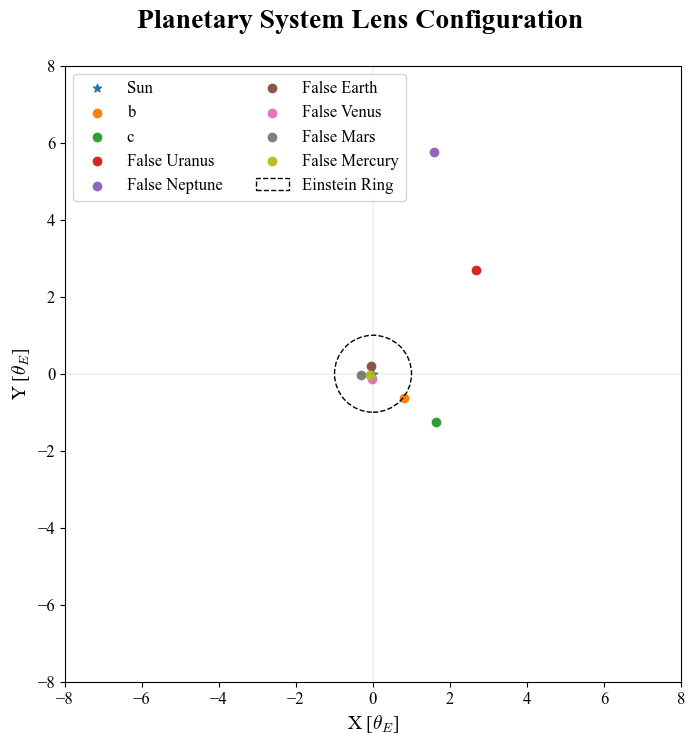

In [5]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Planetary System Lens Configuration', y=0.95)

for i in range(lens_att.shape[0]):
    ax.scatter(lens_att[i, 0], lens_att[i, 1], label=planet_attributes['Planet'].iloc[i-1] if i != 0 else 'Sun', marker='*' if i == 0 else 'o')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
ax.add_patch(ring_patch)

ax.set_aspect('equal')

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

view = 8
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(ncol=2, loc='best')

# fig.savefig('Lens Configuration.png', dpi=300)

plt.show()

Creating magnification maps

Binary offset: [0.0006765 0.       ]
[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]]
4    b
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
Annulus bounds: y+ = 1.7014326379427267, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:01<00:00, 262.84it/s]


---------------------
Total time: 1.935 seconds
Plotting magnification map: 0.017 seconds


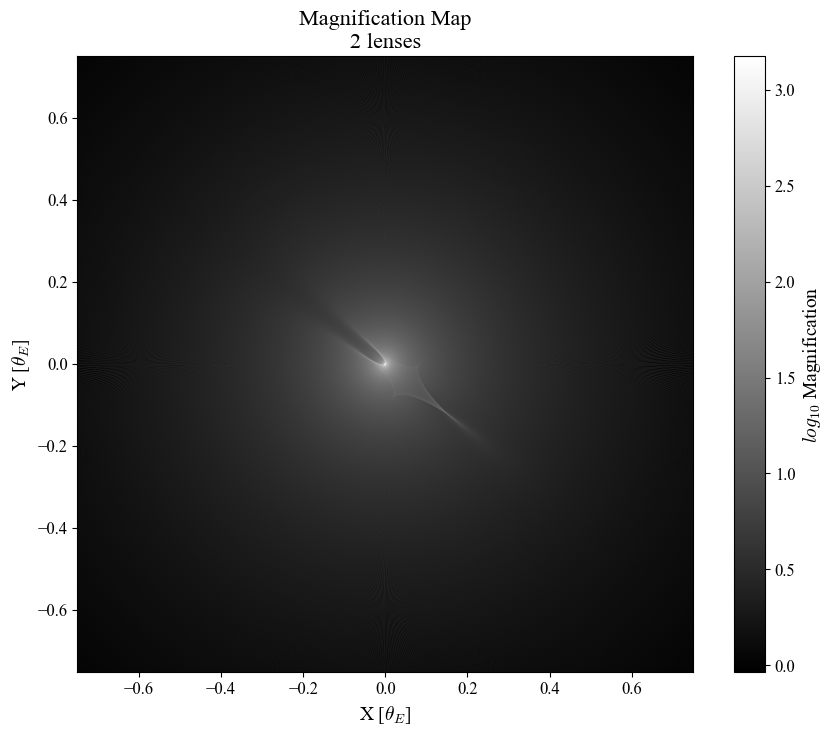

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]]
4    b
5    c
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
Annulus bounds: y+ = 1.7014326379427267, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 249.05it/s]


---------------------
Total time: 2.011 seconds
Plotting magnification map: 0.014 seconds


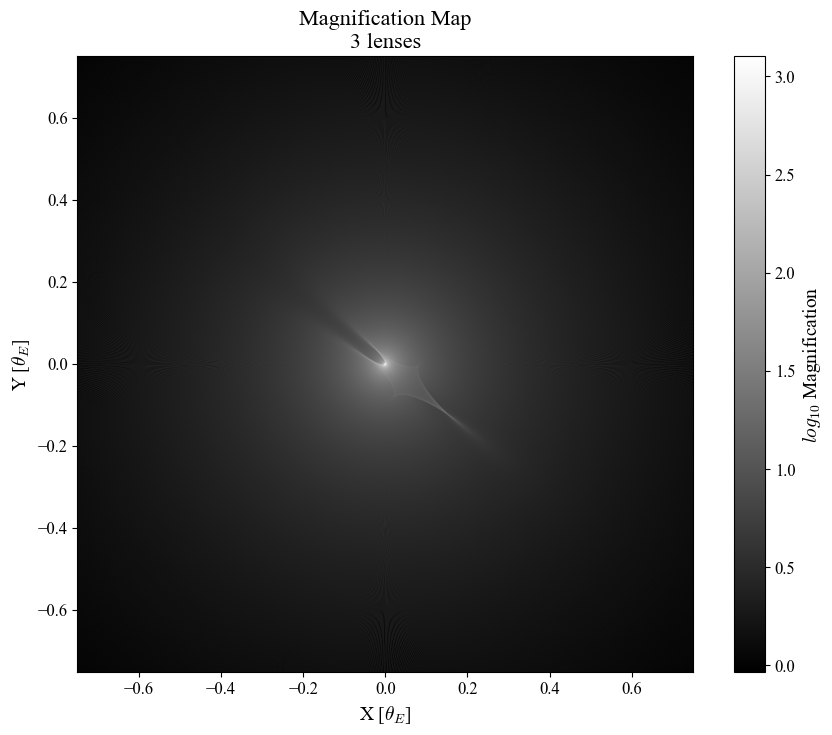

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]]
4               b
5               c
6    False Uranus
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
Annulus bounds: y+ = 1.7014326379427267, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 221.71it/s]


---------------------
Total time: 2.259 seconds
Plotting magnification map: 0.015 seconds


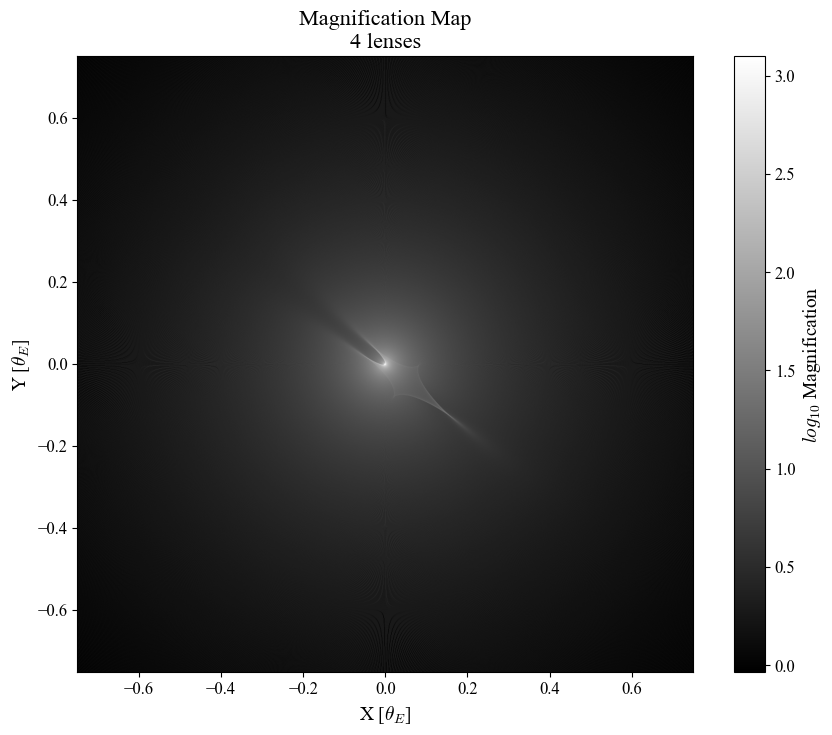

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]]
4                b
5                c
6     False Uranus
7    False Neptune
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
Annulus bounds: y+ = 1.7014326379427267, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 218.06it/s]


---------------------
Total time: 2.297 seconds
Plotting magnification map: 0.014 seconds


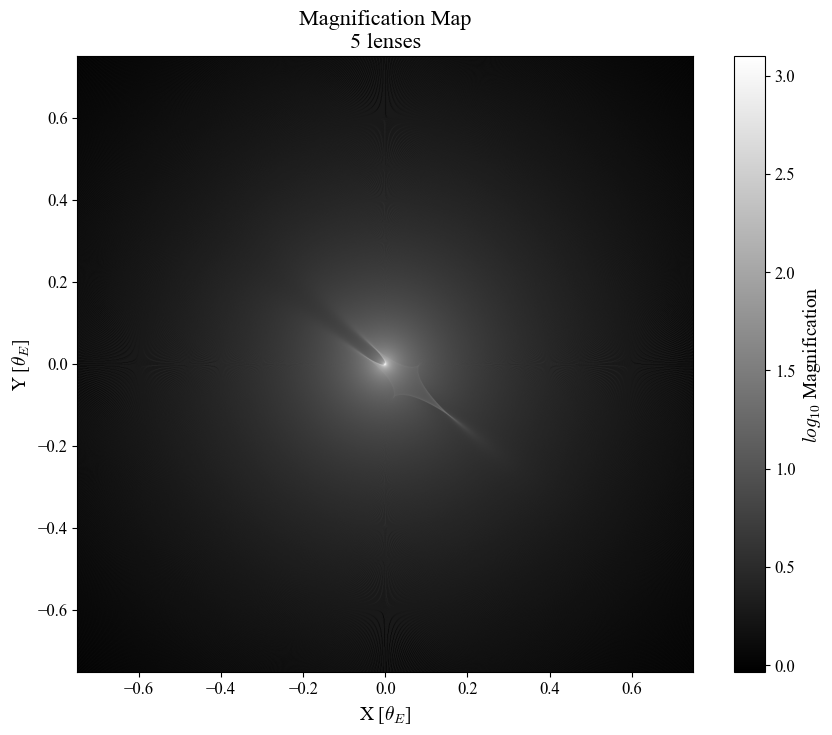

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.198548772091963
Annulus bounds: y+ = 1.7014330329661838, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 206.20it/s]


---------------------
Total time: 2.428 seconds
Plotting magnification map: 0.014 seconds


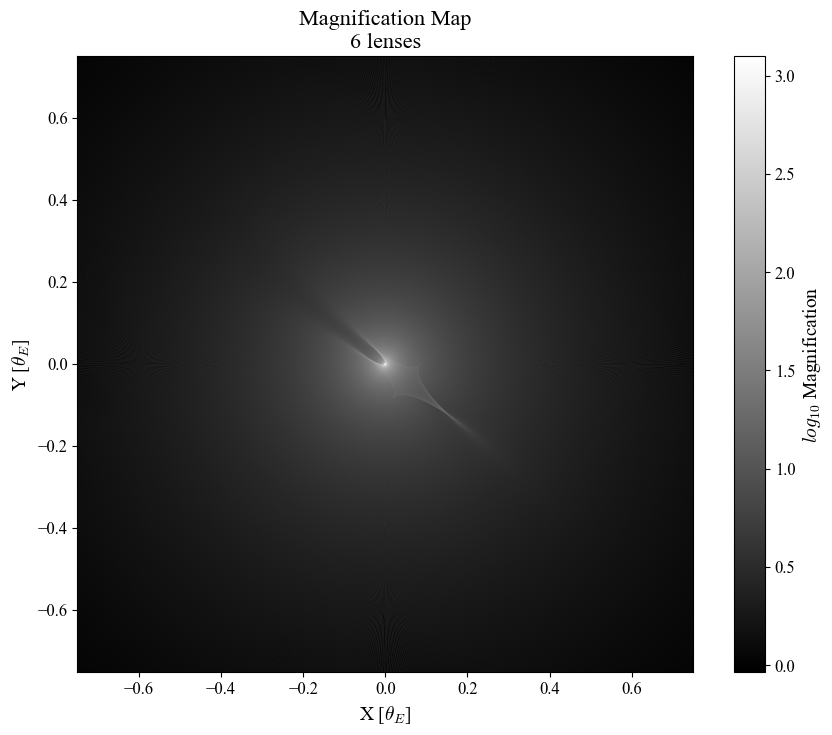

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]
 [-3.79917664e-02 -1.38615988e-01  3.47593262e-06]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
1      False Venus
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.198548772091963
q = 3.4759326211585397e-06, s = 0.14355076222248925
Annulus bounds: y+ = 1.7014330329662288, y- = 0.587148243918636, Min Magnification in

100%|██████████| 500/500 [00:02<00:00, 198.57it/s]


---------------------
Total time: 2.521 seconds
Plotting magnification map: 0.013 seconds


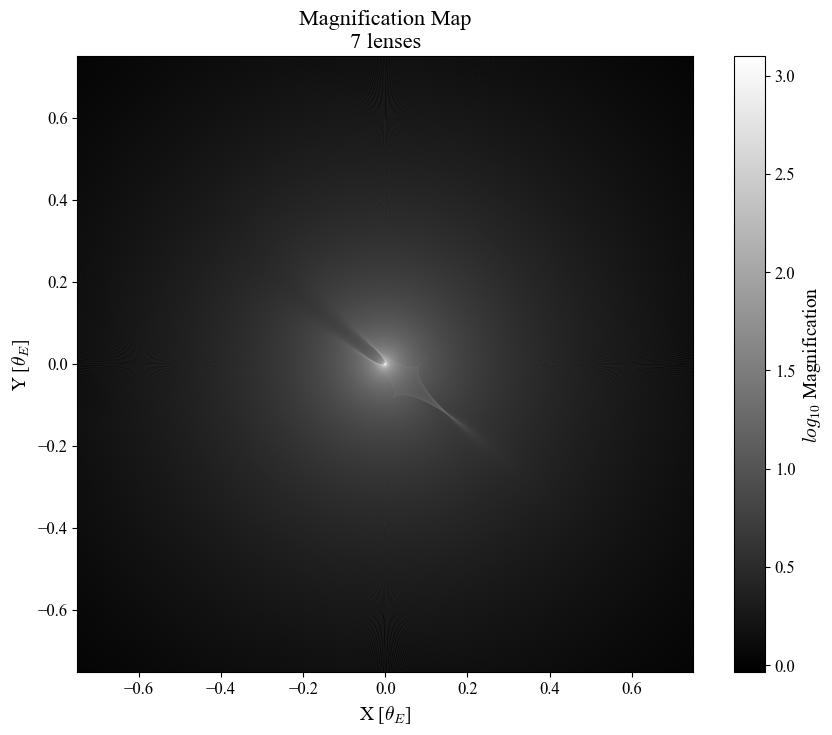

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]
 [-3.79917664e-02 -1.38615988e-01  3.47593262e-06]
 [-3.02564858e-01 -2.05697679e-02  4.58256137e-07]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
1      False Venus
3       False Mars
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.198548772091963
q = 3.4759326211585397e-06, s = 0.14355076222248925
q = 4.582561372

100%|██████████| 500/500 [00:02<00:00, 168.25it/s]


---------------------
Total time: 2.975 seconds
Plotting magnification map: 0.014 seconds


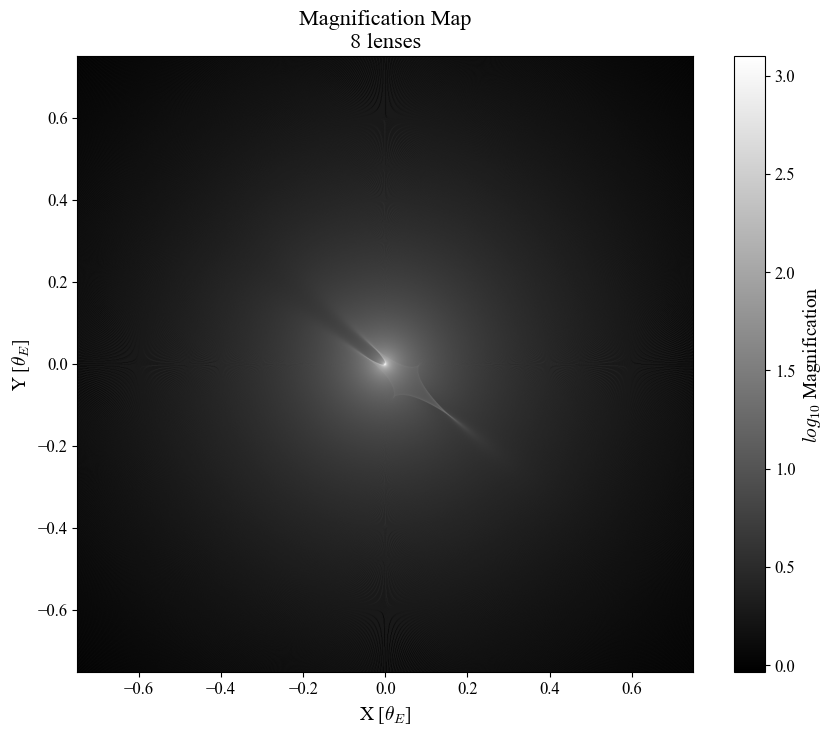

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]
 [-3.79917664e-02 -1.38615988e-01  3.47593262e-06]
 [-3.02564858e-01 -2.05697679e-02  4.58256137e-07]
 [-7.36341793e-02 -2.41104289e-02  2.35739204e-07]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
1      False Venus
3       False Mars
0    False Mercury
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.1985487720919

ValueError: Wrong number of solutions to the binary-lens equation.
Got 2 and expected 3 or 5. (m1=0.9999997642608515, m2=2.3573914863681933e-07, z1=(-0.07683837479958969+0j), zeta=(1.0368548055692226+0j))

In [6]:
center_of_magnification = np.array([planet_attributes['q'].iloc[0] / ((1 + planet_attributes['q'].iloc[0]) * (planet_attributes['s'].iloc[0] + 1/planet_attributes['s'].iloc[0])), 0])
print(f'Binary offset: {center_of_magnification}')

lens_att[:, :2] -= center_of_magnification

# Iterating over all planets and consecutively creating magnification maps
for i in range(len(planets)):
    current_lens_att = lens_att[0:i+2, :]
    print(current_lens_att)
    current_planets = planet_attributes['Planet'].iloc[0:i+1]
    print(current_planets)

    pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(current_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
    ang_width = 1.5
    print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

    (y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
    print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

    num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
    print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}, Total number of rays: {(num_r * num_theta):.3e}')

    lens_parameters = {
        'pixels': 1000,
        'ang_width': ang_width,
        'thickness': y_plus - y_minus,
        'y_plus': y_plus,
        'y_minus': y_minus,
        'lens_att': current_lens_att.tolist(),
        'num_theta': 5000,
        'num_r': 20000
    }
    
    sim_current_lens = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
    magnifications_current_lens = sim_current_lens.series_calculate(cm_offset='auto')
    sim_current_lens.plot()

    plt.show()

In [16]:
i = 8

current_lens_att = lens_att[0:i+2, :]
print(current_lens_att)
current_planets = planet_attributes['Planet'].iloc[0:i+1]
print(current_planets)

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(current_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
ang_width = 3
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}, Total number of rays: {(num_r * num_theta):.3e}')

lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': current_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_current_lens = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_current_lens = sim_current_lens.series_calculate(cm_offset='auto')
sim_current_lens.plot()

plt.show()

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]
 [-3.79917664e-02 -1.38615988e-01  3.47593262e-06]
 [-3.02564858e-01 -2.05697679e-02  4.58256137e-07]
 [-7.36341793e-02 -2.41104289e-02  2.35739204e-07]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
1      False Venus
3       False Mars
0    False Mercury
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 3, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.198548772091963

ValueError: Wrong number of solutions to the binary-lens equation.
Got 2 and expected 3 or 5. (m1=0.9999997642608515, m2=2.3573914863681933e-07, z1=(-0.07683837479958969+0j), zeta=(2.150547985938035+0j))

In [7]:
f'{current_planets.str.join("_")}.pkl'

'4    J_u_p_i_t_e_r\n5      S_a_t_u_r_n\n6      U_r_a_n_u_s\n7    N_e_p_t_u_n_e\n2        E_a_r_t_h\n1        V_e_n_u_s\n3          M_a_r_s\n0    M_e_r_c_u_r_y\nName: Planet, dtype: object.pkl'

In [ ]:
file_name = current_planets.iloc[0]
for i, planet in enumerate(current_planets.values):
    if i != 0:
        file_name += f'_{planet}'

file_name += '.pkl'

file_name

'Jupiter_Saturn_Uranus_Neptune_Earth_Venus_Mars_Mercury.pkl'